In [54]:
import pandas as pd 
import numpy as np 
import spacy 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
corpus = pd.read_csv("../result.csv",sep="~",            
    engine="python", encoding="utf-8",on_bad_lines="skip")
corpus

,fecha,titulo,cuerpo,url,categoria,fuente
0,2025-08-26,YouTube hizo inesperado movimiento con intelig...,La plataforma de entretenimiento YouTube cuent...,https://www.semana.com//tecnologia/articulo/yo...,tecnologia,Semana
1,2025-08-26,Apple reveló la fecha de lanzamiento del iPhon...,Apple celebrará un nuevo evento de presentació...,https://www.semana.com//tecnologia/articulo/ap...,tecnologia,Semana
2,2025-08-21,La estrella más lejana conocida puede no serlo...,"Eärendel, un objeto descubierto en 2022 con el...",https://www.semana.com//tecnologia/articulo/la...,tecnologia,Semana
3,2025-08-08,Por primera vez en la historia: investigadores...,Un equipo de especialistas en ciberseguridad r...,https://www.semana.com//tecnologia/articulo/po...,tecnologia,Semana
4,2025-08-28,No solo es la inteligencia artificial: esta es...,"Para muchos ha resultado sorprendente cómo, en...",https://www.semana.com//tecnologia/articulo/no...,tecnologia,Semana
...,...,...,...,...,...,...
6297,25 de agosto de 2025,El público será jurado en la nueva versión de ...,El Canal RCN adquirió los derechos de Miss Uni...,https://www.elcolombiano.com/entretenimiento/r...,television,El Colombiano
6298,28 de agosto de 2025,¿Qué pasó con el pan? Polémica en el Desafío d...,En el último capítulo del reality fueron varia...,https://www.elcolombiano.com/entretenimiento/t...,television,El Colombiano
6299,01 de septiembre de 2025,Estas son las series y películas que llegarán ...,Si ya no tiene qué ver en plataformas de strea...,https://www.elcolombiano.com/entretenimiento/t...,television,El Colombiano
6300,19 de agosto de 2025,“Es una serie que exalta la latinidad”: el act...,"Si no ha visto Acapulco , la comedia que ya ll...",https://www.elcolombiano.com/entretenimiento/t...,television,El Colombiano


# ¿Hay datos faltantes o documentos vacíos?


In [10]:
corpus.isna().sum()

fecha          0
titulo         0
cuerpo       278
url            0
categoria      0
fuente         0
dtype: int64

# Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.


In [12]:
corpus.categoria.value_counts()

categoria
deportes                         688
politica                         623
gente                            617
mundo                            611
nacion                           606
tecnologia                       528
confidenciales                   361
turismo                          356
loterias                         331
semana-tv                        211
vehiculos                        200
como                             170
opinion                          113
hablan-las-marcas                 74
cultura                           63
mejor-colombia                    56
finanzas                          46
educacion                         45
tendencias                        45
salud                             44
economia                          44
antioquia                         42
colombia                          34
entretenimiento                   33
negocios                          31
especiales                        30
foros-semana/foros-anteriore

### Hay muchas categorias que se podrian agrupar de alguna forma debido a que pueden ser redundantes


In [23]:
mapping = {


    "deportes": "deportes",
    "futbol": "deportes",
    "formula-1": "deportes",
    "atletico-nacional": "deportes",
    "independiente-medellin": "deportes",



    "politica": "politica_gobierno",
    "nacion": "politica_gobierno",
    "seguridad": "politica_gobierno",
    "paz-y-derechos-humanos": "politica_gobierno",



    "gente": "sociedad_cultura",
    "cultura": "sociedad_cultura",
    "opinion": "sociedad_cultura",
    "educacion": "sociedad_cultura",
    "literatura": "sociedad_cultura",
    "musica": "sociedad_cultura",
    "mascotas": "sociedad_cultura",



    "mundo": "internacional",
    "como": "internacional",



    "tecnologia": "tecnologia_ciencia",
    "gadgets": "tecnologia_ciencia",
    "ciencia": "tecnologia_ciencia",
    "videojuegos": "tecnologia_ciencia",



    "finanzas": "economia_negocios",
    "economia": "economia_negocios",
    "negocios": "economia_negocios",
    "empresas": "economia_negocios",


    "semana-tv": "entretenimiento",
    "cine": "entretenimiento",
    "moda": "entretenimiento",
    "tendencias": "entretenimiento",
    "entretenimiento": "entretenimiento",


    "turismo": "estilo_vida",
    "hablan-las-marcas": "estilo_vida",
    "sostenible": "estilo_vida",
    "medio-ambiente": "estilo_vida",
    "movilidad": "estilo_vida",
    "obras": "estilo_vida",


    "confidenciales": "confidenciales_especiales",
    "especiales": "confidenciales_especiales",
    "foros-semana/foros-anteriores": "confidenciales_especiales",
    "mejor-colombia": "confidenciales_especiales",


    "antioquia": "regiones",
    "medellin": "regiones",
    "colombia": "regiones"}


corpus["categoria_agrupada"] = corpus["categoria"].map(mapping)
corpus["categoria_agrupada"].value_counts()
conteos = corpus["categoria_agrupada"].value_counts()
conteos 

categoria_agrupada
politica_gobierno            1247
sociedad_cultura              865
internacional                 781
deportes                      724
tecnologia_ciencia            555
estilo_vida                   477
confidenciales_especiales     474
entretenimiento               307
economia_negocios             130
regiones                       90
Name: count, dtype: int64

C:\Users\alejo\AppData\Local\Temp\ipykernel_5308\3512079987.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


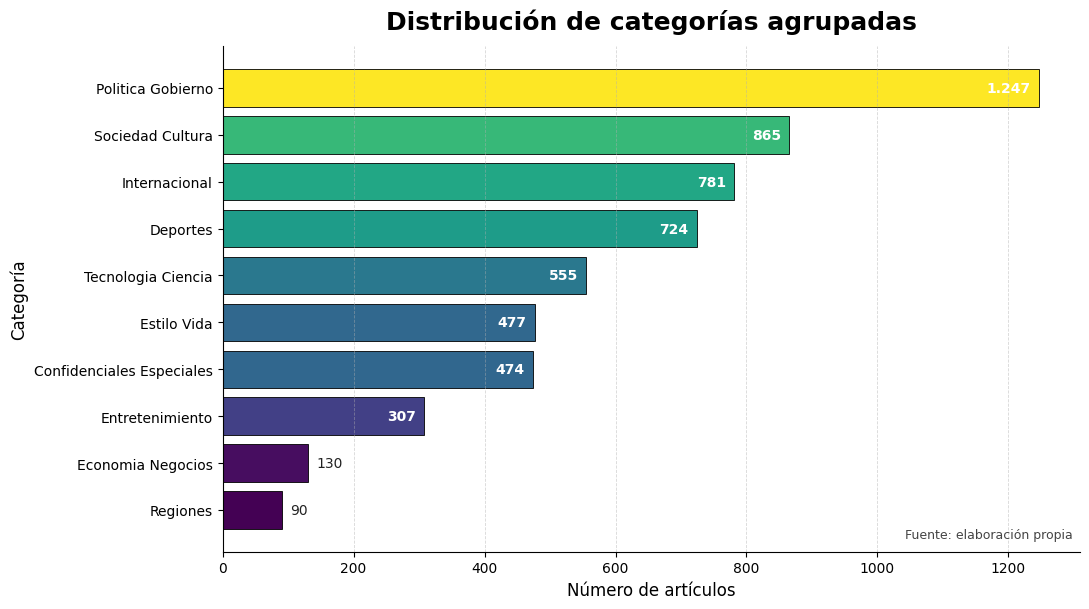

In [ ]:
from matplotlib import cm

grouped = conteos.sort_values(ascending=True)

def plot_categorias(data, titulo="Distribución de categorías agrupadas"):
    
    if isinstance(data, pd.DataFrame):
        df = data[['categoria_agrupada','count']].copy()
        df = df.sort_values('count', ascending=True)
        cats = df['categoria_agrupada'].astype(str).tolist()
        vals = df['count'].astype(float).to_numpy()
    else:  
        s = data.astype(float).sort_values(ascending=True)
        cats = s.index.astype(str).tolist()
        vals = s.to_numpy()

    cats_pretty = [c.replace('_',' ').title() for c in cats]

    vmin, vmax = vals.min(), vals.max()
    norm = (vals - vmin) / (vmax - vmin + 1e-9)
    cmap = cm.get_cmap('viridis')
    colors = cmap(norm)

    plt.figure(figsize=(11, 6.2))
    bars = plt.barh(cats_pretty, vals, color=colors, edgecolor='black', linewidth=0.6)
    plt.title(titulo, fontsize=18, fontweight='bold', pad=12)
    plt.xlabel("Número de artículos", fontsize=12)
    plt.ylabel("Categoría", fontsize=12)
    plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    for spine in ['top','right']:
        plt.gca().spines[spine].set_visible(False)

    xmin, xmax = 0, vals.max()
    plt.xlim(xmin, xmax * 1.05)
    threshold_inside = xmax * 0.12  
    for rect, v in zip(bars, vals):
        y = rect.get_y() + rect.get_height()/2
        label = f"{int(v):,}".replace(',', '.') 
        if v >= threshold_inside:
            plt.text(rect.get_x() + v - (xmax*0.01), y, label,
                     va='center', ha='right', fontsize=10, color='white', fontweight='bold')
        else:
            plt.text(rect.get_x() + v + (xmax*0.01), y, label,
                     va='center', ha='left', fontsize=10, color='#222')

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.annotate("Fuente: elaboración propia", xy=(1, 0), xycoords='axes fraction',xytext=(-5, 8), textcoords='offset points',ha='right', va='bottom', fontsize=9, color='#444')
    plt.tight_layout()
    plt.show()

plot_categorias(conteos)

### De este modo las clases estan un poco mas balanceadas

---


## Categegorias por Periodico


C:\Users\alejo\AppData\Local\Temp\ipykernel_5308\3512079987.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


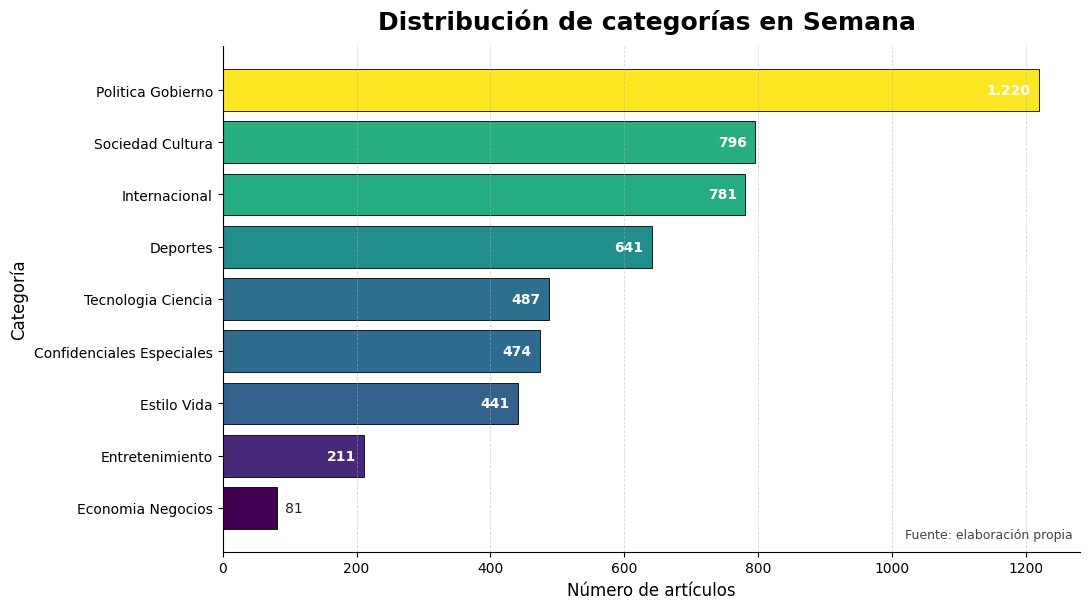

In [32]:
conteos_semana = corpus[corpus['fuente'] == 'Semana']['categoria_agrupada'].value_counts()
plot_categorias(conteos_semana , titulo="Distribución de categorías en Semana ")

C:\Users\alejo\AppData\Local\Temp\ipykernel_5308\3512079987.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


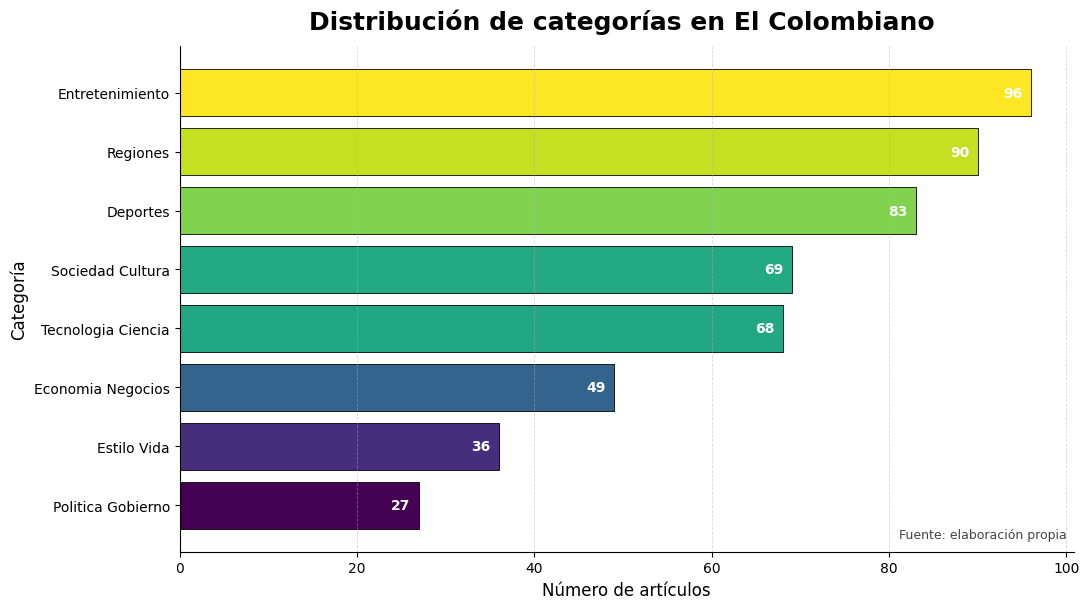

In [34]:
conteos_colombiano = corpus[corpus['fuente'] == 'El Colombiano']['categoria_agrupada'].value_counts()
plot_categorias(conteos_colombiano , titulo="Distribución de categorías en El Colombiano ")

## Analisis de noticas por Fecha


C:\Users\alejo\AppData\Local\Temp\ipykernel_5308\968439622.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


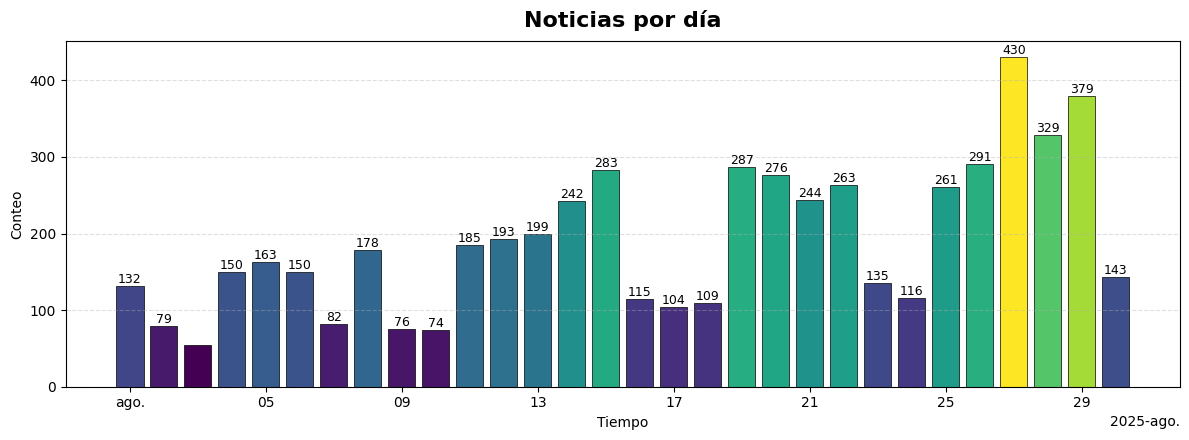

In [50]:
import matplotlib.dates as mdates

corpus['fecha'] = pd.to_datetime(corpus['fecha'], errors='coerce', utc=True).dt.tz_localize(None)


def conteos_por_intervalo(df, freq='W'):

    s = (df.set_index('fecha')
         .sort_index().resample(freq).size().rename('n'))
    return s.reset_index()


def plot_barras_temporales(df_count, titulo="Eventos por intervalo"):
    x = df_count['fecha']
    y = df_count['n'].astype(int)

    norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
    cmap = cm.get_cmap("viridis")  
    colors = cmap(norm)

    plt.figure(figsize=(12, 4.5))
    plt.bar(x, y, color=colors, edgecolor="black", linewidth=0.5)

    ax = plt.gca()
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.title(titulo, fontsize=16, fontweight='bold', pad=10)
    plt.xlabel("Tiempo")
    plt.ylabel("Conteo")

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    ymax = y.max()
    thresh = max(5, int(0.15 * ymax)) 
    for xi, yi in zip(x, y):
        if yi >= thresh:
            plt.text(xi, yi, f"{yi:,}".replace(',', '.'), ha='center', va='bottom', fontsize=9, color="black")

    plt.tight_layout()
    plt.show()


def plot_linea_area(df_count, titulo="Serie temporal de eventos", rol_window=4):
    x = df_count['fecha']
    y = df_count['n'].astype(float)

    media = y.mean()
    rol = y.rolling(rol_window, min_periods=max(1, rol_window//2)).mean()

    line_color = "#1f77b4"  
    rol_color = "#ff7f0e"   
    area_color = cm.get_cmap("Blues")(0.3)  

    plt.figure(figsize=(12, 4.8))
    plt.fill_between(x, y, color=area_color, alpha=0.3)
    plt.plot(x, y, color=line_color, linewidth=2, marker='o', markersize=4, label="Conteo")
    plt.plot(x, rol, color=rol_color, linewidth=2, linestyle='--', label=f"Media móvil ({rol_window})")
    plt.axhline(media, linestyle=':', linewidth=2, color="red", alpha=0.7,label=f"Media = {media:.0f}")

    ax = plt.gca()
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.title(titulo, fontsize=16, fontweight='bold', pad=10)
    plt.xlabel("Tiempo")
    plt.ylabel("Conteo")
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend(frameon=False)
    top_idx = np.argsort(y.values)[-3:]
    for i in top_idx:
        plt.scatter(x.iloc[i], y.iloc[i], color=line_color, s=60, zorder=3)
        plt.text(x.iloc[i], y.iloc[i] * 1.02, 
                 f"{int(y.iloc[i]):,}".replace(',', '.'), 
                 va='bottom', ha='center', fontsize=9, fontweight='bold', color=line_color)

    plt.tight_layout()
    plt.show()

diario = conteos_por_intervalo(corpus, freq='D')
plot_barras_temporales(diario, titulo="Noticias por día")

C:\Users\alejo\AppData\Local\Temp\ipykernel_5308\968439622.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  area_color = cm.get_cmap("Blues")(0.3)


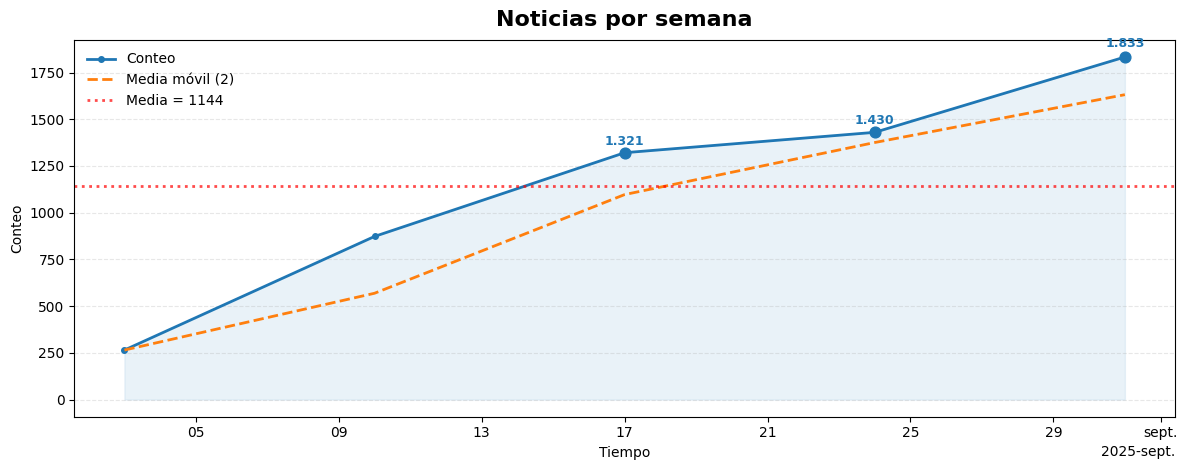

In [51]:
semanal = conteos_por_intervalo(corpus, freq='W') 
plot_linea_area(semanal, titulo="Noticias por semana", rol_window=2)  

## Analice los documentos, y determine cuál es la distribución de la longitud de los documentos a nivel carácter o palabra.


In [52]:
corpus['len_char'] = corpus['cuerpo'].astype(str).str.len()
corpus['len_word'] = corpus['cuerpo'].astype(str).str.split().str.len()

print("=== Longitud en caracteres ===")
print(corpus['len_char'].describe())

print("\n=== Longitud en palabras ===")
print(corpus['len_word'].describe())

=== Longitud en caracteres ===
count     6302.000000
mean      2731.850682
std       1562.394941
min          3.000000
25%       2190.000000
50%       2646.500000
75%       3124.750000
max      35411.000000
Name: len_char, dtype: float64

=== Longitud en palabras ===
count    6302.000000
mean      442.516820
std       254.155198
min         1.000000
25%       353.000000
50%       427.000000
75%       504.000000
max      5573.000000
Name: len_word, dtype: float64


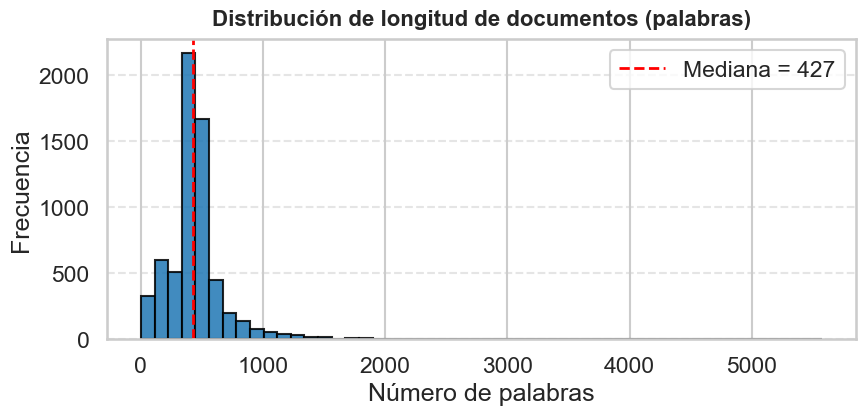

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(9, 4.5))
plt.hist(corpus['len_word'], bins=50, edgecolor='black', alpha=0.85)
plt.title("Distribución de longitud de documentos (palabras)", fontsize=16, fontweight='bold', pad=10)
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axvline(corpus['len_word'].median(), color='red', linestyle='--', linewidth=2,
            label=f"Mediana = {corpus['len_word'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

## Nube para el corupus


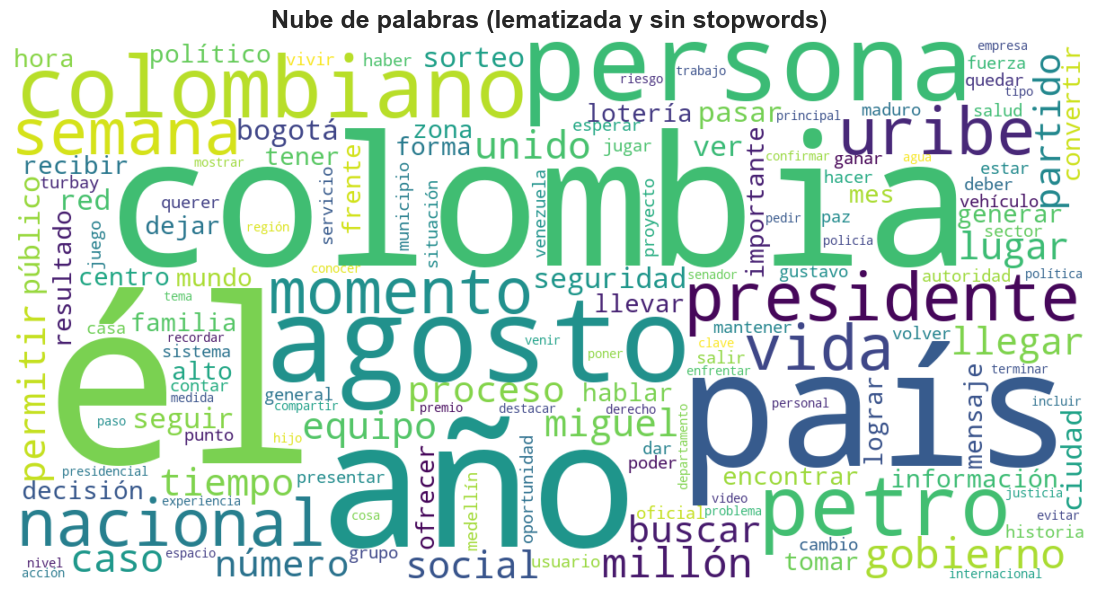

In [ ]:
from wordcloud import WordCloud
from spacy.attrs import IS_STOP, IS_PUNCT, IS_ALPHA, LEMMA

nlp = spacy.load("es_core_news_sm")

def lemmas_filtrados_docs(texts, batch_size=512, n_process=4):
    vocab_strings = nlp.vocab.strings
    lemas_ids_all = []

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process,disable=["ner", "parser"]):
        
        arr = doc.to_array([IS_STOP, IS_PUNCT, IS_ALPHA, LEMMA])  
        mask = (~arr[:,0].astype(bool)) & (~arr[:,1].astype(bool)) & (arr[:,2].astype(bool))
        lemas_ids_all.append(arr[mask, 3]) 

    lemas_ids_all = np.concatenate(lemas_ids_all) if lemas_ids_all else np.array([], dtype=np.int64)
    return [vocab_strings[lem_id].lower() for lem_id in lemas_ids_all]


texts = corpus['cuerpo'].dropna().astype(str)
tokens_filtrados = lemmas_filtrados_docs(texts)
texto_filtrado = " ".join(tokens_filtrados)

wordcloud = WordCloud(width=1200, height=600,background_color='white',max_words=150,
                      colormap='viridis',collocations=False).generate(texto_filtrado)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras (lematizada y sin stopwords)", fontsize=18, fontweight='bold', pad=10)
plt.show()

## Nube para los titulos de las noticas


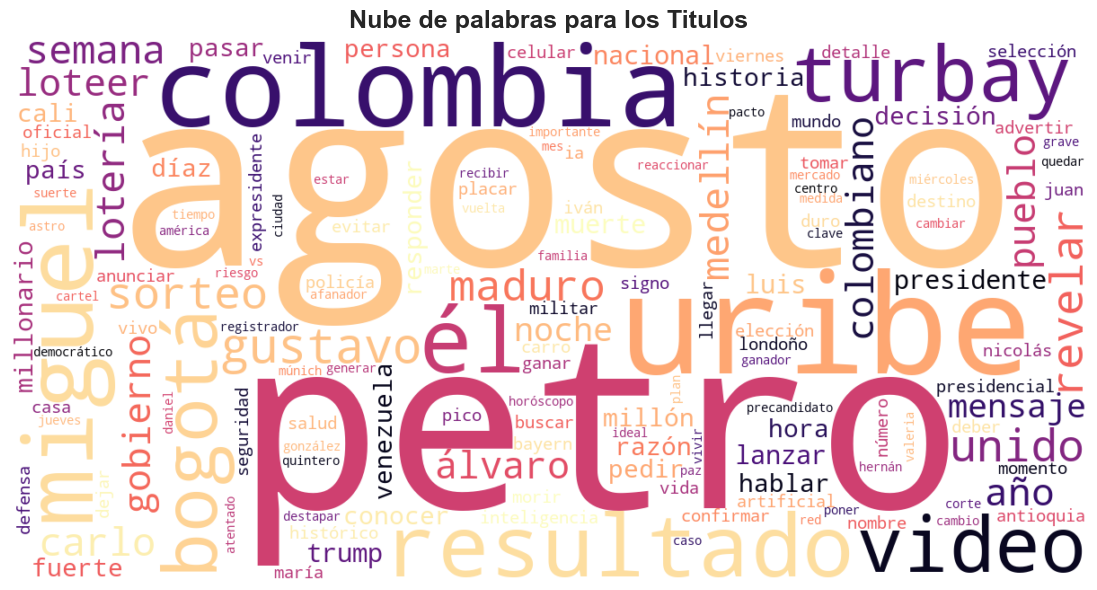

In [69]:
texts = corpus['titulo'].dropna().astype(str)
tokens_filtrados = lemmas_filtrados_docs(texts)
texto_filtrado = " ".join(tokens_filtrados)

wordcloud = WordCloud(width=1200, height=600, background_color='white',max_words=150,
                      colormap='magma',collocations=False).generate(texto_filtrado)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras para los Titulos", fontsize=18, fontweight='bold', pad=10)
plt.show()

---


## BiGramas y TriGramas


In [71]:
from collections import Counter

docs = list(nlp.pipe(corpus['cuerpo'].dropna().astype(str), disable=["ner", "parser"]))

tokens_filtrados = []
for doc in docs:
    for token in doc:
        if not token.is_stop and not token.is_punct and token.is_alpha:
            tokens_filtrados.append(token.lemma_.lower())

bigramas = Counter(zip(tokens_filtrados, tokens_filtrados[1:]))
trigramas = Counter(zip(tokens_filtrados, tokens_filtrados[1:], tokens_filtrados[2:]))


print("=== Top 15 Bigramas ===")
for (w1, w2), c in bigramas.most_common(15):
    print(f"{w1} {w2}: {c}")

print("\n=== Top 15 Trigramas ===")
for (w1, w2, w3), c in trigramas.most_common(15):
    print(f"{w1} {w2} {w3}: {c}")

=== Top 15 Bigramas ===
miguel uribe: 1457
gustavo petro: 1335
red social: 1244
uribe turbay: 1173
sorteo lotería: 1003
presidente gustavo: 757
inteligencia artificial: 630
llevar cabo: 616
centro democrático: 570
álvaro uribe: 548
millón pesos: 530
nicolás maduro: 522
precandidato presidencial: 492
número suerte: 438
uribe londoño: 411

=== Top 15 Trigramas ===
miguel uribe turbay: 955
presidente gustavo petro: 753
expresidente álvaro uribe: 301
agosto llevar cabo: 287
álvaro uribe vélez: 270
llevar cabo sorteo: 268
miguel uribe londoño: 256
cabo sorteo lotería: 239
ganador sorteo lotería: 225
ofrecer posibilidad ganar: 217
ganar premio millonario: 215
posibilidad ganar premio: 215
sorteo transmitir vivo: 213
resultado consultar página: 212
premio millonario modalidad: 211


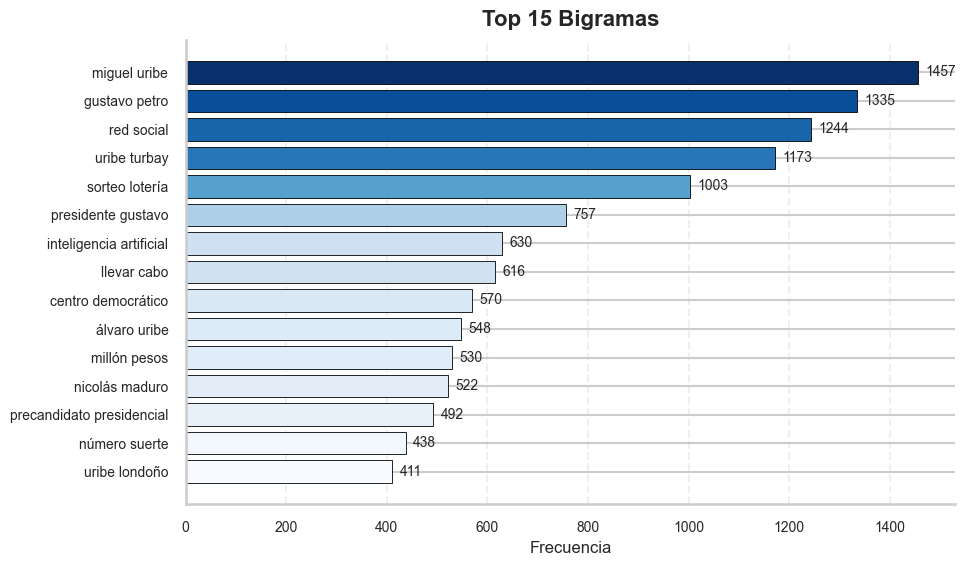

In [79]:
top_bigrams = bigramas.most_common(15)
labels = [f"{w1} {w2}" for (w1, w2), _ in top_bigrams]
counts = np.array([c for _, c in top_bigrams])

norm = (counts - counts.min()) / (counts.max() - counts.min() + 1e-9)
colors = plt.colormaps.get_cmap("Blues")(norm) 

plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], counts[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
plt.title("Top 15 Bigramas", fontsize=16, fontweight="bold", pad=10)
plt.xlabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for bar, value in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + counts.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             str(value),
             va='center', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

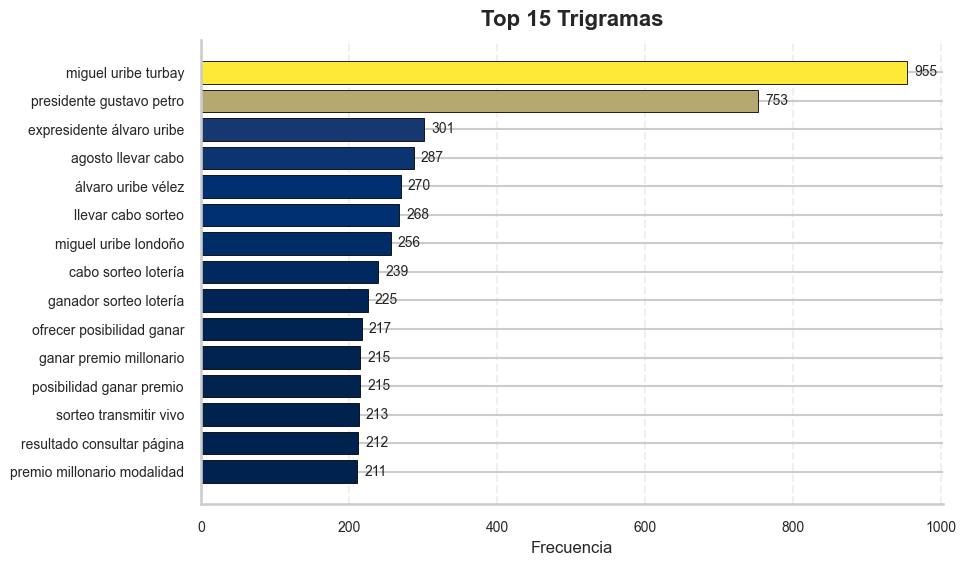

In [80]:
top_trigrams = trigramas.most_common(15)
labels = [f"{w1} {w2} {w3}" for (w1, w2, w3), _ in top_trigrams]
counts = np.array([c for _, c in top_trigrams])
norm = (counts - counts.min()) / (counts.max() - counts.min() + 1e-9)
colors = plt.colormaps.get_cmap("cividis")(norm)  

plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], counts[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
plt.title("Top 15 Trigramas", fontsize=16, fontweight="bold", pad=10)
plt.xlabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for bar, value in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + counts.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             str(value),
             va='center', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()